**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Clase 12 - Casos de aplicación en organizaciones**

La clase pasada encontramos el óptimo de decisiones que dependían de **una sola variable**: cuánto
pedir, cuánto producir, a qué precio vender.

Hoy damos el paso siguiente: **decisiones con dos variables a la vez**. Cuánto trabajo y cuánto
capital. Cuánto presupuesto a un programa y cuánto al otro. La herramienta para eso es la
**derivada parcial**, y la lógica es la misma de siempre: derivar, igualar a cero, interpretar.

| | El caso | La decisión |
|---|---|---|
| **Caso 1** | Presupuesto público entre dos programas | ¿Cuánto a cada uno? |
| **Caso 2** | Trabajo y capital en una automotriz | ¿Qué combinación minimiza el costo? |

> 🎯 **La idea que atraviesa los dos casos:** en el óptimo, **el último peso puesto en cada opción
> rinde lo mismo**. Si no fuera así, convendría mover plata de una a la otra.

# Derivada Parcial 😎

> Antes de avanzar con el siguiente caso primero aprendamos que es una derivada parcial, una herramienta muy util cuando debemos analizar la variacion de una variable respecto a otra.
>> Veamos un ejemplo:


🧠 ¿Qué es una derivada parcial?
Cuando tenés una función con varias variables, como:

$$f(x,y) = 5x^2 + 2y^2$$

La derivada parcial te dice cómo cambia la función cuando solo cambia una variable y las demás se mantienen constantes.

$$\frac{\partial f}{\partial x}=10x$$$$\frac{\partial f}{\partial y}=4y$$




In [1]:
# 🔧 Librerías necesarias
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.optimize import minimize

In [2]:

# Definir variables simbólicas
x, y = sp.symbols('x y')

# Definir la función
f = 5*x**2 + 2*y**2

# Derivadas parciales
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)

# Mostrar resultados
print("Función: f(x, y) =", f)
print("Derivada parcial respecto a x (∂f/∂x):", df_dx)
print("Derivada parcial respecto a y (∂f/∂y):", df_dy)


Función: f(x, y) = 5*x**2 + 2*y**2
Derivada parcial respecto a x (∂f/∂x): 10*x
Derivada parcial respecto a y (∂f/∂y): 4*y


In [3]:
f


5*x**2 + 2*y**2

In [4]:
df_dx

10*x

In [5]:
df_dy

4*y

Hace sentido con lo que veniamos hablando. Veamos otro ejemplo:
$$f(x,y) = x^2 * y^2$$

In [6]:
# Definir variables simbólicas
x, y = sp.symbols('x y')

# Definir la función
f = x**2 * y**2

# Derivadas parciales
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)

# Mostrar resultados
print("Función: f(x, y) =", f)
print("Derivada parcial respecto a x (∂f/∂x):", df_dx)
print("Derivada parcial respecto a y (∂f/∂y):", df_dy)

Función: f(x, y) = x**2*y**2
Derivada parcial respecto a x (∂f/∂x): 2*x*y**2
Derivada parcial respecto a y (∂f/∂y): 2*x**2*y


Sigamos:
$$f(q,l) = q^2 - l^2 + q + l$$

In [7]:
# Definir variables simbólicas
q, l = sp.symbols('q l')

# Definir la función
f = q**2 - l**2 + q + l

# Derivadas parciales
df_dq = sp.diff(f, q, )
df_dl = sp.diff(f, l)

# Mostrar resultados
print("Función: f(q, l) =", f)
print("Derivada parcial respecto a x (∂f/∂q):", df_dq)
print("Derivada parcial respecto a y (∂f/∂l):", df_dl)

Función: f(q, l) = -l**2 + l + q**2 + q
Derivada parcial respecto a x (∂f/∂q): 2*q + 1
Derivada parcial respecto a y (∂f/∂l): 1 - 2*l


Sigamos:
$$f(x,y) = xy - y^2 + x + 8$$

In [8]:
# resuelva

<details>
<summary>💡 <b>Ver solución</b></summary>

```python
x, y = sp.symbols('x y')

f = x*y - y**2 + x + 8

df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)

print("Función: f(x, y) =", f)
print("Derivada parcial respecto a x (∂f/∂x):", df_dx)
print("Derivada parcial respecto a y (∂f/∂y):", df_dy)

# ¿Hay punto crítico? Las dos parciales tienen que anularse a la vez
print("\nPuntos críticos:", sp.solve([df_dx, df_dy], [x, y], dict=True))
```

**Lo que hay que ver.** $\partial f/\partial x = y + 1$ y $\partial f/\partial y = x - 2y$.

Fijate en algo que no pasaba en los ejemplos anteriores: **la derivada respecto de $x$ depende de
$y$**. Eso significa que las dos variables **interactúan**: cuánto aporta mover $x$ depende de dónde
esté parado $y$. El culpable es el término $xy$.

Es la diferencia entre este caso y el primero ($5x^2 + 2y^2$), donde cada parcial dependía solo de su
propia variable y las decisiones eran **separables**: se podía optimizar $x$ sin mirar $y$. Cuando hay
un término cruzado eso se rompe, y **hay que resolver el sistema**.

El punto crítico existe y es $y = -1$, $x = -2$.

</details>


Que pasa si agregamos una variable mas?
$$f(x,y,z) = xy - y^2 + x + z$$

In [9]:
#resuelva
# f(x, y, z) = x*y - y**2 + x + z

x, y, z = sp.symbols('x y z')

# Definir la función
f = x*y - y**2 + x + z

# Derivadas parciales: una por cada variable
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)
df_dz = sp.diff(f, z)

print("df/dx =", df_dx)
print("df/dy =", df_dy)
print("df/dz =", df_dz)

# El punto crítico es donde las tres derivadas se anulan a la vez
critico = sp.solve([df_dx, df_dy, df_dz], [x, y, z], dict=True)
print("Puntos críticos:", critico)

# df/dz = 1 nunca se anula: esta función NO tiene punto crítico.
# Interpretación: z siempre suma, así que conviene aumentarla sin límite.

df/dx = y + 1
df/dy = x - 2*y
df/dz = 1
Puntos críticos: []


Proponga una ecuacion y escribala con latex en el markdown y a continuacion resuelvala


In [10]:
# :D



---



---
# 🏛️ Caso 1: repartir un presupuesto público

Hasta acá optimizamos decisiones **de una empresa**. Pero la misma matemática resuelve un problema
que aparece todos los años en cualquier ministerio, municipio o universidad:

> **Hay un presupuesto fijo y varios programas donde ponerlo. ¿Cuánto va a cada uno?**

**La situación.** Un municipio tiene \$ 500 millones para dos programas de un plan de empleo:

| Programa | Qué hace | Personas capacitadas |
|---|---|---|
| **A — Formación en oficios** | Cursos presenciales, talleres | $30\sqrt{x_A}$ |
| **B — Alfabetización digital** | Cursos online, más masivo | $45\sqrt{x_B}$ |

(con $x$ en millones de pesos asignados a cada programa)

**¿Por qué raíz cuadrada?** Porque los dos programas tienen **rendimientos decrecientes**: los
primeros millones capacitan muchísima gente (los que estaban esperando), y a medida que se agranda
hay que ir a buscar gente cada vez más difícil de alcanzar. Es exactamente lo que pasa en la
realidad, y es la razón por la que **volcar todo el presupuesto en un solo programa nunca es óptimo**.

In [11]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

PRESUPUESTO = 500     # millones de pesos

xA, xB = sp.symbols("x_A x_B", positive=True)

# Cuánta gente capacita cada programa
personas_A = 30 * sp.sqrt(xA)
personas_B = 45 * sp.sqrt(xB)

# La restricción: todo lo que no va a A, va a B
total = personas_A.subs(xA, xA) + personas_B.subs(xB, PRESUPUESTO - xA)

print("Personas capacitadas en total:", total)

# Optimizamos en una sola variable (la restricción ya está adentro)
derivada = sp.diff(total, xA)
xA_opt = sp.solve(sp.Eq(derivada, 0), xA)[0]
xB_opt = PRESUPUESTO - xA_opt

print(f"\nAsignación óptima:")
print(f"   Programa A (oficios) : $ {float(xA_opt):6.1f} millones")
print(f"   Programa B (digital) : $ {float(xB_opt):6.1f} millones")
print(f"   Personas capacitadas : {float(total.subs(xA, xA_opt)):,.0f}")

Personas capacitadas en total: 30*sqrt(x_A) + 45*sqrt(500 - x_A)



Asignación óptima:
   Programa A (oficios) : $  153.8 millones
   Programa B (digital) : $  346.2 millones
   Personas capacitadas : 1,209


In [12]:
# ¿Qué pasa si el intendente decide poner todo en un solo programa?
def capacitados(asignado_a_A):
    return 30 * np.sqrt(asignado_a_A) + 45 * np.sqrt(PRESUPUESTO - asignado_a_A)

escenarios = {
    "Todo al programa A":        499.9,
    "Mitad y mitad":             250.0,
    "Óptimo calculado":          float(xA_opt),
    "Todo al programa B":          0.1,
}

for nombre, valor in escenarios.items():
    print(f"{nombre:<22} → {capacitados(valor):8,.0f} personas")

Todo al programa A     →      685 personas
Mitad y mitad          →    1,186 personas
Óptimo calculado       →    1,209 personas
Todo al programa B     →    1,016 personas


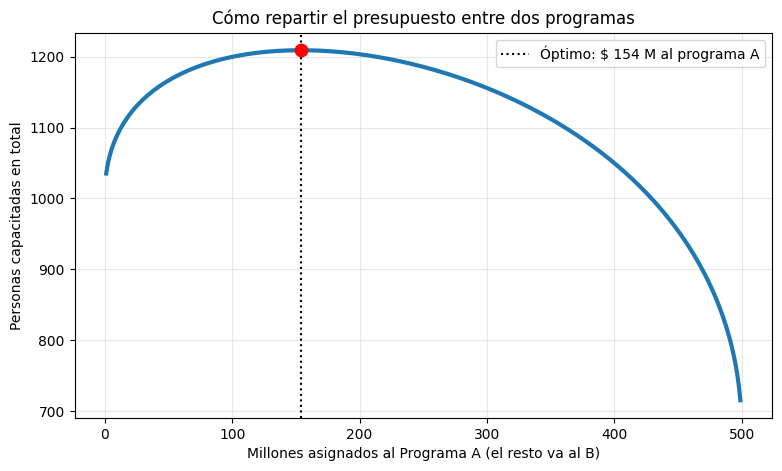

In [13]:
# El gráfico completo: cuánta gente se capacita según cómo se reparta
x_vals = np.linspace(1, PRESUPUESTO - 1, 400)
y_vals = capacitados(x_vals)

plt.figure(figsize=(9, 5))
plt.plot(x_vals, y_vals, linewidth=3)
plt.axvline(float(xA_opt), color='black', linestyle=':',
            label=f"Óptimo: $ {float(xA_opt):.0f} M al programa A")
plt.scatter([float(xA_opt)], [capacitados(float(xA_opt))], color='red', s=80, zorder=5)
plt.xlabel("Millones asignados al Programa A (el resto va al B)")
plt.ylabel("Personas capacitadas en total")
plt.title("Cómo repartir el presupuesto entre dos programas")
plt.legend()
plt.grid(alpha=.3)
plt.show()

### 🧠 La regla que se esconde acá

Mirá el resultado: **al programa B le toca más plata, pero no toda**. Y eso pasa aunque B sea más
eficiente en todos los tramos.

La condición del óptimo tiene una lectura clarísima, y es la misma en un ministerio que en una empresa:

> **En el punto óptimo, el último peso puesto en cada programa rinde lo mismo.**

Si el último peso en A capacitara más gente que el último peso en B, convendría mover plata de B
hacia A. Se mueve hasta que se emparejan: ahí ya no hay nada que ganar reasignando.

**Por eso los extremos son malos.** Poner todo en el programa "más eficiente" ignora que su
rendimiento **cae** a medida que crece. Es el error más común en la discusión pública de un
presupuesto: se compara el promedio de cada programa, cuando lo que hay que comparar es **el margen**.

| Lo que se suele preguntar | Lo que habría que preguntar |
|---|---|
| ¿Qué programa es más eficiente? | ¿Cuánto rinde **el próximo peso** en cada programa? |
| ¿Cuánto le dimos el año pasado? | ¿Sigue rindiendo igual con más presupuesto? |

> 💼 **Y es exactamente el mismo problema** que repartir un presupuesto de marketing entre canales,
> horas de un equipo entre proyectos, o inversión entre sucursales. Cambia el nombre, no la matemática.

In [14]:
# Para practicar: verificá la regla del "último peso"
# Calculá la derivada de cada programa por separado, evaluada en el óptimo.
# Si la regla es cierta, los dos números tienen que dar IGUAL.

# Tu código acá

<details>
<summary>💡 <b>Ver solución</b></summary>

```python
# La derivada de cada programa POR SEPARADO es lo que rinde el próximo peso
rinde_A = sp.diff(personas_A, xA)
rinde_B = sp.diff(personas_B, xB)

print("Rendimiento marginal de A:", rinde_A)
print("Rendimiento marginal de B:", rinde_B)

# Evaluados en el óptimo
marginal_A = float(rinde_A.subs(xA, xA_opt))
marginal_B = float(rinde_B.subs(xB, xB_opt))

print(f"\nEn el óptimo:")
print(f"   El próximo millón en A capacita: {marginal_A:.4f} personas")
print(f"   El próximo millón en B capacita: {marginal_B:.4f} personas")
print(f"   Diferencia: {abs(marginal_A - marginal_B):.10f}  ← cero ✅")

# Y fuera del óptimo NO se cumple: ahí conviene reasignar
for prueba in [80, 153.85, 300]:
    mA = float(rinde_A.subs(xA, prueba))
    mB = float(rinde_B.subs(xB, PRESUPUESTO - prueba))
    quien = "→ mover plata de B hacia A" if mA > mB else (
            "→ mover plata de A hacia B" if mB > mA else "→ ya está óptimo")
    print(f"\nSi A recibe {prueba:6.2f}: marginal A = {mA:.4f}, marginal B = {mB:.4f}  {quien}")
```

**Lo que confirma.** Los dos rendimientos marginales dan **exactamente lo mismo** en el óptimo. Esa
igualdad **es** la condición de primer orden: cuando derivamos el total e igualamos a cero, lo que
estábamos escribiendo sin darnos cuenta era

$$\frac{d(\text{personas}_A)}{dx_A} = \frac{d(\text{personas}_B)}{dx_B}$$

porque un peso que entra a A es un peso que sale de B.

Y mirá el último bloque: **fuera** del óptimo los marginales difieren, y el que sea más grande te dice
**hacia dónde conviene mover plata**. Eso es lo útil en la práctica: no hace falta recalcular el
óptimo desde cero para saber si la asignación actual está mal — alcanza con comparar los dos
marginales y ver cuál gana.

</details>


# 🚗 Caso 2: Optimización de trabajo y capital en la industria automotriz

Imaginemos a "AutoFuturo S.A.", una nueva empresa automotriz que busca establecer una línea de producción para un modelo de vehículo eléctrico innovador. Para ser competitivos, necesitan minimizar los costos de fabricación para alcanzar una meta de producción de 100 vehículos por día.

La producción de cada vehículo requiere una combinación de dos factores clave:

*   **Trabajo (L):** La mano de obra especializada (ingenieros, técnicos, operarios) que ensambla y supervisa el proceso. El costo de una unidad de trabajo (por ejemplo, horas de mano de obra calificada) es de \$10.
*   **Capital (K):** La maquinaria, robots, herramientas y tecnología utilizada en la línea de ensamblaje. El costo de una unidad de capital (por ejemplo, horas de uso de maquinaria avanzada) es de \$5.

La tecnología de producción de AutoFuturo S.A. se describe mediante la siguiente función de producción:

$$Q(L, K) = \sqrt{L \cdot K}$$

Donde:
*   $Q$ es la cantidad de vehículos producidos por día.
*   $L$ es la cantidad de unidades de trabajo utilizadas.
*   $K$ es la cantidad de unidades de capital utilizadas.

Esta función de producción, una forma de Cobb-Douglas, implica que tanto el trabajo como el capital son necesarios para la producción y que hay rendimientos a escala constantes (si duplicas tanto L como K, duplicas la producción).

AutoFuturo S.A. tiene como objetivo producir exactamente 100 vehículos por día. Por lo tanto, la restricción de producción es:

$$\sqrt{L \cdot K} = 100$$

O, elevando ambos lados al cuadrado:
$$L \cdot K = 10000$$

El costo total de producción ($C$) depende de las cantidades de trabajo ($L$) y capital ($K$) utilizadas y de sus respectivos precios ($w=10$ para el trabajo y $r=5$ para el capital):

$$C(L, K) = wL + rK = 10L + 5K$$


**El Desafío de AutoFuturo S.A.:** 🚗

El desafío para AutoFuturo S.A. es encontrar la combinación óptima de trabajo ($L^*$) y capital ($K^*$) que les permita producir los 100 vehículos diarios al menor costo total posible.

Este problema se resuelve utilizando técnicas de optimización restringida. Gráficamente, esto implica encontrar el punto donde una curva de isocosto (que representa todas las combinaciones de L y K que cuestan lo mismo) es tangente a la isocuanta (que representa todas las combinaciones de L y K que producen 100 unidades).

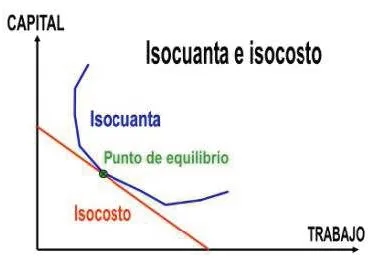

El objetivo es encontrar $L^*$ y $K^*$ tales que $10L^* + 5K^*$ sea mínimo, cumpliendo siempre la condición $\sqrt{L^* \cdot K^*} = 100$. La solución a este problema indicará a AutoFuturo S.A. cuántas unidades de trabajo y capital deben emplear para fabricar sus 100 vehículos eléctricos de la manera más eficiente en costos.

In [15]:
# Función de costo
def costo(x):
    L, K = x
    return 10*L + 5*K  # Costo total

# Restricción: producir 100 unidades
def restriccion(x):
    L, K = x
    return (L * K)**0.5 - 100

# Llamamos al optimizador
res = minimize(costo, x0=[10, 10], constraints={'type': 'eq', 'fun': restriccion})

# Mostramos los resultados
L_opt, K_opt = res.x
print(f"L* = {L_opt:.2f}")
print(f"K* = {K_opt:.2f}")
print(f"Costo mínimo = {costo([L_opt, K_opt]):.2f}")
C_opt = costo([L_opt, K_opt])

L* = 70.71
K* = 141.42
Costo mínimo = 1414.21


Perfect --> Sabemos las cantidades optimas de trabajo y capital que precisa la automotriz para producir 100 unidades de automoviles, arrojando un costo minimo de \$1414,21

## Gráfico del caso 🙂


1.  **Calcular la Isocuanta:** Se utilizó la restricción de producción $L \cdot K = 10000$ (derivada de $\sqrt{L \cdot K} = 100$) para despejar $K$ en función de $L$. La ecuación de la isocuanta es $K = \frac{10000}{L}$.

2.  **Calcular la Isocosto Óptima:** Se utilizó el costo mínimo (`C_opt`) encontrado previamente por el optimizador. La ecuación general de una línea de isocosto es $C = wL + rK$. Despejando $K$: $K = \frac{C - wL}{r}$. Con $w=10$, $r=5$ y el costo mínimo `C_opt`, la ecuación de la isocosto óptima es $K = \frac{C_{opt} - 10L}{5}$. Se definió una función `isocosto(L, C)` para calcular estos valores de K para diferentes valores de L a un costo fijo C. Luego se graficó `L_vals` contra `isocosto(L_vals, C_opt)` para dibujar la línea de isocosto que pasa por el punto óptimo.

3.  **Marcar el Punto Óptimo:** Los valores óptimos de Trabajo (`L_opt`) y Capital (`K_opt`) obtenidos del resultado de la optimización (`res.x`) se graficaron como un punto rojo ('ro') para mostrar visualmente la combinación de L y K que minimiza el costo.


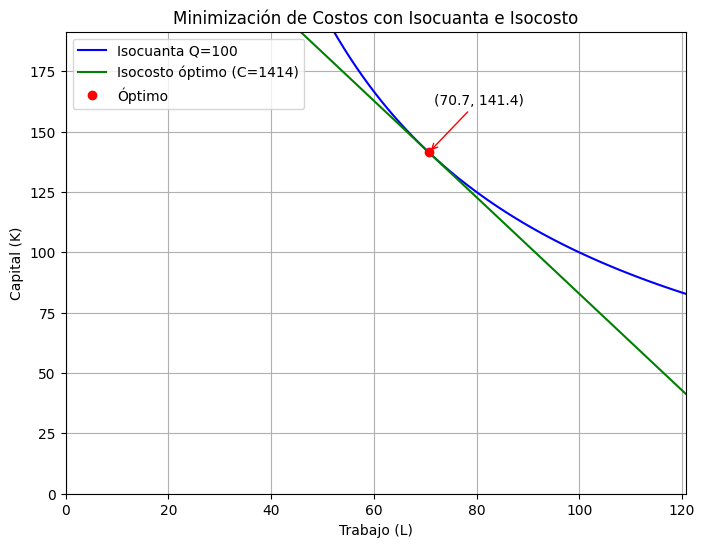

In [16]:
# Rango para graficar
L_vals = np.linspace(1, L_opt + 50, 100)
K_vals_isoq = (100**2) / L_vals  # K = (Q^2) / L

# Función de isocosto
def isocosto(L, C): return (C - 10*L) / 5

# Gráfico
plt.figure(figsize=(8,6))
plt.plot(L_vals, K_vals_isoq, label='Isocuanta Q=100', color='blue')
plt.plot(L_vals, isocosto(L_vals, C_opt), label=f'Isocosto óptimo (C={C_opt:.0f})', color='green')

# Punto óptimo
plt.plot(L_opt, K_opt, 'ro', label='Óptimo')
plt.annotate(f'({L_opt:.1f}, {K_opt:.1f})',
             xy=(L_opt, K_opt), xytext=(L_opt+1, K_opt+20),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=10)

# Ajuste de ejes
plt.xlim(0, L_opt + 50)
plt.ylim(0, K_opt + 50)

plt.xlabel("Trabajo (L)")
plt.ylabel("Capital (K)")
plt.title("Minimización de Costos con Isocuanta e Isocosto")
plt.legend()
plt.grid(True)
plt.show()


### 🧮 ¿Y las derivadas parciales? La condición detrás del resultado

`minimize` nos dio el número, pero no nos dijo **por qué** ese número. Y como toda esta clase empezó
con derivadas parciales, vale la pena cerrar el círculo: el óptimo que encontró SciPy se puede
deducir a mano, y la deducción usa exactamente lo que vimos al principio.

Las derivadas parciales de la función de producción se llaman **productividades marginales**: cuánto
más se produce al agregar una unidad más de cada factor.

$$PMg_L = \frac{\partial Q}{\partial L} \qquad\qquad PMg_K = \frac{\partial Q}{\partial K}$$

Y la condición de costo mínimo es **la misma regla del último peso del Caso 1**, escrita con dos
factores en vez de dos programas:

$$\frac{PMg_L}{w} = \frac{PMg_K}{r}$$

**Léase:** *el último peso gastado en trabajo tiene que producir lo mismo que el último peso gastado
en capital.* Si el peso puesto en máquinas rindiera más que el puesto en gente, convendría correr
presupuesto hacia las máquinas — y se corre hasta que se emparejan.

Reordenando queda la forma con la que suele aparecer en los libros:

$$\underbrace{\frac{PMg_L}{PMg_K}}_{\text{lo que dice la tecnología}} = \underbrace{\frac{w}{r}}_{\text{lo que dice el mercado}}$$

El lado izquierdo es la **relación marginal de sustitución técnica**, y es la pendiente de la
isocuanta. El derecho es la pendiente de la isocosto. Que sean iguales es, literalmente, **que las
dos curvas del gráfico de arriba sean tangentes**.


In [17]:
# Resolvamos el mismo problema a mano, con derivadas parciales
L, K, lam = sp.symbols("L K lambda", positive=True)

w, r, Q_META = 10, 5, 100

Q_prod = sp.sqrt(L * K)

# Productividades marginales = las derivadas parciales
PMg_L = sp.diff(Q_prod, L)
PMg_K = sp.diff(Q_prod, K)

print("Q(L,K)  =", Q_prod)
print("PMg_L   =", sp.simplify(PMg_L))
print("PMg_K   =", sp.simplify(PMg_K))
print("\nRMST = PMg_L / PMg_K =", sp.simplify(PMg_L / PMg_K), "  ← la pendiente de la isocuanta")

# Las dos condiciones del óptimo:
#   1) el último peso rinde lo mismo en cada factor
#   2) hay que llegar a la meta de producción
condicion_tangencia = sp.Eq(PMg_L / w, PMg_K / r)
condicion_produccion = sp.Eq(Q_prod, Q_META)

solucion = sp.solve([condicion_tangencia, condicion_produccion], [L, K], dict=True)[0]

print(f"\nResolviendo el sistema a mano:")
print(f"   L* = {float(solucion[L]):.4f}")
print(f"   K* = {float(solucion[K]):.4f}")
print(f"   Costo = {float(w*solucion[L] + r*solucion[K]):.4f}")
print(f"\nLo que había dado SciPy: L* = {L_opt:.4f}, K* = {K_opt:.4f}, costo = {C_opt:.4f}")
print("\n✅ Mismo resultado. SciPy resolvió numéricamente este sistema.")


Q(L,K)  = sqrt(K)*sqrt(L)
PMg_L   = sqrt(K)/(2*sqrt(L))
PMg_K   = sqrt(L)/(2*sqrt(K))

RMST = PMg_L / PMg_K = K/L   ← la pendiente de la isocuanta

Resolviendo el sistema a mano:
   L* = 70.7107
   K* = 141.4214
   Costo = 1414.2136

Lo que había dado SciPy: L* = 70.7107, K* = 141.4213, costo = 1414.2136

✅ Mismo resultado. SciPy resolvió numéricamente este sistema.


> 💼 **Por qué conviene saber las dos formas.** El método de SciPy funciona siempre, incluso cuando
> el sistema no se puede despejar. Pero la condición analítica dice algo que el número solo no dice:
> **que la mezcla óptima depende de la relación de precios $w/r$, no de los precios por separado**.
>
> Eso tiene una consecuencia práctica inmediata. Si mañana suben el trabajo y el capital en la misma
> proporción (una devaluación, inflación pareja), la **combinación** óptima de $L$ y $K$ **no cambia**:
> lo único que cambia es el costo total. En cambio, si sube solo el trabajo, la empresa
> **sustituye hacia el capital**. Eso es lo que hay atrás de "la automatización responde al costo
> laboral relativo", y sale de mirar la fórmula, no el número.

> 🔎 **Nota.** Acá resolvimos el sistema tangencia + restricción, que es lo más directo. El método
> general para optimizar con restricciones se llama **multiplicadores de Lagrange**, y `lam` en la
> celda de arriba está declarado justamente por eso, aunque no lo usemos. Queda para la materia de
> Matemática, pero es útil saber que el nombre existe y que es esto mismo, sistematizado.


---
# 📝 Ejercicios de práctica


### ✅ Ejercicio 1 — Minimización de costos con restricción 

Una empresa produce utilizando trabajo ($L$) y capital ($K$) con la siguiente función de producción:

$$Q(L, K) = L^{0.4} K^{0.6}$$

El costo del trabajo es $w = 15$ y el del capital es $r = 10$, y la empresa quiere producir
exactamente **200 unidades**:

$$C(L, K) = 15L + 10K$$

**Se pide:**

1. Plantear el problema: minimizar $C(L,K)$ sujeto a $L^{0.4}K^{0.6} = 200$.
2. Resolverlo con `scipy.optimize.minimize` usando una restricción de igualdad, como en el Caso 2.
   Prestá atención al `x0` y a los `bounds`.
3. Calcular el costo mínimo.



In [22]:
# Tu código acá


# Bibliografia y Recomendaciones 📚



*   Libros =

    1.  Big data de walter sosa escudero.
    2.  Viajar al futuro de walter sosa escudero.


In [24]:
#@title Easter egg 🥚
from IPython.display import Image
Image(url='https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExc3lzMzFhcXJhOTJ3MDNpZDhmYXUyMzZ2eWdpZnQ0d2FtYm43ODhhZyZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/mGK1g88HZRa2FlKGbz/giphy.gif')